In [79]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np
from src import soporte_datasets as sp_datasets

# Visualización
# -----------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Imputación de nulos usando métodos avanzados estadísticos
# -----------------------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer


# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [80]:
df_final = pd.read_csv('files/customer_flight_loyalty.csv') 
df_final.head(2)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,province,city,postal_code,gender,education,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,salary
0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,Married,Aurora,7919.20,Standard,2016,8,False,False,92552.0
1,100102,2017,1,10,4,14,2030,203.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,Single,Nova,2887.74,Standard,2013,3,False,False,66937.5


In [81]:
df_final.columns

Index(['loyalty_number', 'year', 'month', 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed',
       'province', 'city', 'postal_code', 'gender', 'education',
       'marital_status', 'loyalty_card', 'clv', 'enrollment_type',
       'enrollment_year', 'enrollment_month', 'cancellation_year',
       'cancellation_month', 'salary'],
      dtype='str')

In [82]:
#Análisis de variables numéricas

df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
flights_booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
flights_with_companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
total_flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
points_accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
points_redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00
dollar_cost_points_redeemed,403760.0,2.495973,10.172033,0.00,0.00,0.00,0.00,71.00


Podemos interpretar lo siguiente:

    - flights_booked: El 75% de los datos llega a 8, pero el máximo es 21, podemos interpretar presencia de outliers.
    - flights_with_companions: La media está en 1m y el máximo en 11, muy disperso.
    - total_flights: El 75% de los datos llega a 10, pero el máximo es 32, podemos interpretar presencia de outliers.
    - distance: La media es más del doble que la mediana, y el valor máximo está muy alejado del 75% de los datos, presencia de outliers.
    - points_accumulated: La media está en 124 frente a 53 de la mediana (el doble) teniendo un máximo de 676,50, muy disperso.
    - points_redeemed: La media de puntos gastados son 30 mensuales, la mediana se sitúa en 0, teniendo un máximo de 876, datos muy dispersos.
    - dollar_cost_points_redeemed: La media del valor en dólares es 10, la mediana se sitúa en 0, teniendo un máximo de 71$, datos muy dispersos.
    - clv: La media es mayor que la mediana (7990 vs 5776), el 75% de los clientes aportan 8937$ pero tiene cliente(s) que aportan hasta 83325, muy disperso.
    - salary: El salario máximo (407228) es altísimo comparado con la media (76222) o mediana /66937.

    

In [83]:
df_final.columns

Index(['loyalty_number', 'year', 'month', 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed',
       'province', 'city', 'postal_code', 'gender', 'education',
       'marital_status', 'loyalty_card', 'clv', 'enrollment_type',
       'enrollment_year', 'enrollment_month', 'cancellation_year',
       'cancellation_month', 'salary'],
      dtype='str')

# Análisis correlación entre variables numéricas relevantes

*total_flights: Límite superior 25.00 | Límite inferior -15.00 | Cantidad: 1984 (0.49%)

*flights_booked: Límite superior 20.00 | Límite inferior -12.00 | Cantidad: 528 (0.13%)

*distance: Límite superior 5855.00 | Límite inferior -3513.00 | Cantidad: 125 (0.03%)

*clv: Límite superior 16370.13 | Límite inferior -3451.23 | Cantidad: 35941 (8.90%)

*salary: Límite superior 111498.50 | Límite inferior 35342.50 | Cantidad: 20876 (5.17%)

*points_accumulated: Límite superior 600.00 | Límite inferior -360.00 | Cantidad: 112 (0.03%)



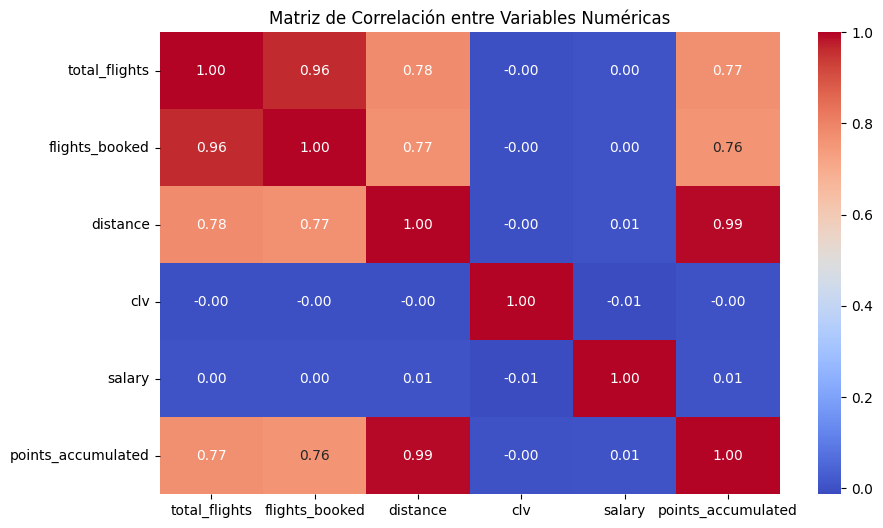

In [84]:
#columnas relevantes numéricas para el estudio:
# 
cols_num = ["total_flights", "flights_booked", "distance",'clv','salary', "points_accumulated"]

for col in cols_num:
    limite_sup,limite_inf, cantidad = sp_datasets.detectar_outliers_iqr(df_final, col)
    porcentaje = (cantidad / len(df_final)) * 100 #los outliers entre el total de datos para sacar el %.
    print(f"*{col}: Límite superior {limite_sup:.2f} | Límite inferior {limite_inf:.2f} | Cantidad: {cantidad} ({porcentaje:.2f}%)\n")


plt.figure(figsize=(10, 6))
correlacion = df_final[cols_num].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()

Interpretación después de sacar los Outliers:

    - total_flights: Cantidad: 1984 (0.49%), el porcentaje es muy bajo, casi no hay valores atípicos.
    - flights_booked: Cantidad: 528 (0.13%), el porcentaje es muy bajo, casi no hay valores atípicos.
    - distance: Cantidad: 125 (0.03%), el porcentaje es muy bajo, casi no hay valores atípicos.
    - clv: Límite superior 16370.13 | Cantidad: 35941 (8.90%), el porcentaje alcanza casi un 9%, significa la cantidad de cientes que aportan más que el límite superior.
    - salary: Límite superior 111498.50 | Límite inferior 35342.50 | Cantidad: 20876 (5.17%), quien gane por fuera de los limites.
    - points_accumulated: Cantidad: 112 (0.03%), el porcentaje es muy bajo, casi no hay valores atípicos.

Interpretación después de sacar el heatmap:

- Flights_booked tiene una alta correlación con el total_flights, con distance y con points_accumulated. Relación positiva.

In [85]:
# Clasificamos a los clientes según su CLV
df_final['segment_clv'] = 'Normal' #creo una columna donde todos los valores los detallo como "normal"

#Hago máscara de que los valores que estén por encima del limite superior, lo ponga como outlier, filas, columnas y modifico los datos.
df_final.loc[df_final['clv'] > 16370, 'segment_clv'] = 'Premium (Outlier)' 

In [86]:
df_final["segment_clv"].value_counts() #hago un value_counts para ver cuántos pertenecen dentro y cuántos fuera

segment_clv
Normal               367819
Premium (Outlier)     35941
Name: count, dtype: int64

In [87]:
#salary: Límite superior 111498.50 | Límite inferior 35342.50 | Cantidad: 20876 (5.17%), quien gane por fuera de los limites.

# Clasificamos a los clientes según su salario
df_final['segment_salary'] = 'Normal' #creo una columna donde todos los valores los detallo como "normal"

#Hago máscara de que los valores que estén por encima del limite superior, lo ponga como outlier, filas, columnas y modifico los datos.
df_final.loc[df_final['salary'] > 111498.50, 'segment_salary'] = 'Premium (Outlier)' 

In [88]:
df_final["segment_salary"].value_counts() #hago un value_counts para ver cuántos pertenecen dentro y cuántos fuera

segment_salary
Normal               384787
Premium (Outlier)     18973
Name: count, dtype: int64

In [89]:
df_final.head(5)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,province,city,postal_code,gender,education,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,salary,segment_clv,segment_salary
0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,Married,Aurora,7919.20,Standard,2016,8,False,False,92552.0,Normal,Normal
1,100102,2017,1,10,4,14,2030,203.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,Single,Nova,2887.74,Standard,2013,3,False,False,66937.5,Normal,Normal
2,100140,2017,1,6,0,6,1200,120.0,0,0,British Columbia,Dawson Creek,U5I 4F1,Female,College,Divorced,Nova,2838.07,Standard,2016,7,False,False,66937.5,Normal,Normal
3,100214,2017,1,0,0,0,0,0.0,0,0,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,Married,Star,4170.57,Standard,2015,8,False,False,63253.0,Normal,Normal
4,100272,2017,1,0,0,0,0,0.0,0,0,Ontario,Toronto,P1L 8X8,Female,Bachelor,Divorced,Star,6622.05,Standard,2014,1,False,False,91163.0,Normal,Normal


# Análisis de variables categóricas:

In [90]:
df_final.describe(include=str).T

,count,unique,top,freq
province,403760,11,Ontario,130258
city,403760,29,Toronto,80775
postal_code,403760,55,V6E 3D9,21944
gender,403760,2,Female,202757
education,403760,5,Bachelor,252567
marital_status,403760,3,Married,234845
loyalty_card,403760,3,Star,183745
enrollment_type,403760,2,Standard,380419
cancellation_year,403760,7,False,354110
cancellation_month,403760,13,False,354110


In [93]:
# Lista de variables a analizar
variables_cat = ['loyalty_card', 'education']

for col in variables_cat:
    print(f"\n--- Análisis de Frecuencias: {col} ---")
    
    # Creamos un DataFrame con el conteo y el porcentaje
    frecuencias = pd.DataFrame({
        'Recuento': df_final[col].value_counts(),
        'Porcentaje (%)': (df_final[col].value_counts(normalize=True) * 100).round(2)
    })
    
    print(frecuencias)


--- Análisis de Frecuencias: loyalty_card ---
              Recuento  Porcentaje (%)
loyalty_card                          
Star            183745           45.51
Nova            136883           33.90
Aurora           83132           20.59

--- Análisis de Frecuencias: education ---
                      Recuento  Porcentaje (%)
education                                     
Bachelor                252567           62.55
College                 102260           25.33
High School or Below     18915            4.68
Doctor                   17731            4.39
Master                   12287            3.04


- Ontario es tu provincia principal (más de 130k registros).
- Los "Bachelor" son la gran mayoría (252k).
- La tarjeta "Star" es la más común.
- El tipo de inscripción "Standard" es la gran mayoría (380k)
- Género/Marital Status: Está muy balanceado (Ej. Female aparece como top, pero con 202k sobre 403k totales, está casi al 50%).

Tras el análisis de todas las variables, se observa que aunque la operativa de vuelos es muy uniforme (pocos outliers), existe una gran dispersión en el valor económico de los clientes (CLV).

In [92]:
#¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

df_final[["total_flights", "flights_booked"]].agg("mean")

total_flights     5.170619
flights_booked    4.134050
dtype: float64

# <font color="green">Visualización</font>

### ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

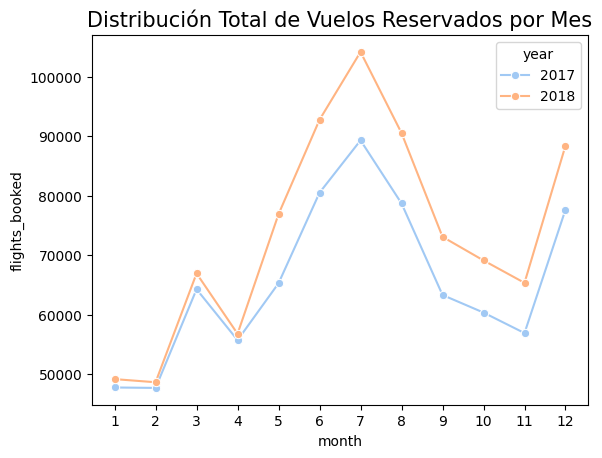

In [107]:
sns.lineplot(data=df_final, x='month', y='flights_booked', hue='year', 
             marker='o', palette='pastel', estimator='sum', errorbar=None)
plt.title('Distribución Total de Vuelos Reservados por Mes', fontsize=15)
plt.xticks(range(1, 13)); # Aseguramos que se vean todos los meses del 1 al 12;

En ambos años existe el siguiente patrón:

- El pico máximo ocurre en Julio.
- Se observa subida constante desde abril/mayo hasta alcanzar Julio.
- Hay una caida en desde Marzo a Abril.
- En Navidad vuelve a subir.

También se puede apreciar que la línea naranja, correpondiente a 2018 está siempre por encima de la azul (2017), esto confirma que ha aumentado los clientes o la frecuencia de viaje de un año para otro.

### ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?

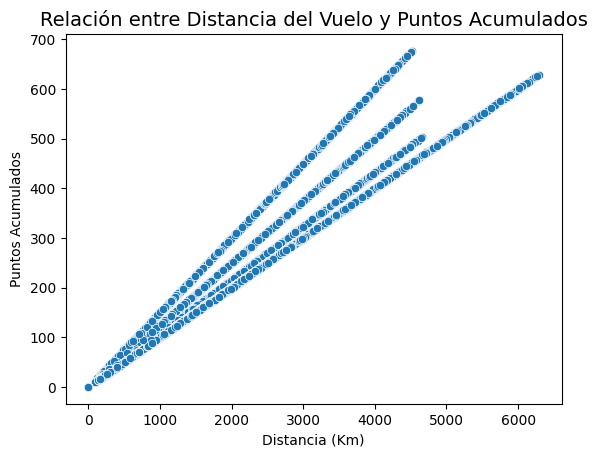

In [109]:
sns.scatterplot(data=df_final, x='distance', y='points_accumulated')

plt.title('Relación entre Distancia del Vuelo y Puntos Acumulados', fontsize=14)
plt.xlabel('Distancia (Km)')
plt.ylabel('Puntos Acumulados')

plt.show()